In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy import stats
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('data\\cleaned_data.csv', parse_dates=['time'], index_col='time')
df

,day,month,year,hour,pm10 (μg/m³),pm2_5 (μg/m³),carbon_monoxide (μg/m³),nitrogen_dioxide (μg/m³),sulphur_dioxide (μg/m³),ozone (μg/m³),aerosol_optical_depth (),dust (μg/m³),uv_index (),uv_index_clear_sky ()
time,,,,,,,,,,,,,,
2022-08-04 07:00:00,4,8,2022,7,11.8,8.3,230.0,3.1,1.0,32.0,0.08,0.0,1.10,1.20
2022-08-04 08:00:00,4,8,2022,8,10.2,7.1,216.0,2.6,0.9,37.0,0.08,0.0,3.25,3.55
2022-08-04 09:00:00,4,8,2022,9,9.3,6.5,195.0,1.8,0.8,43.0,0.08,0.0,6.10,6.95
2022-08-04 10:00:00,4,8,2022,10,9.7,6.8,174.0,1.1,0.8,51.0,0.08,0.0,7.85,10.45
2022-08-04 11:00:00,4,8,2022,11,11.0,7.7,168.0,0.9,0.8,55.0,0.08,0.0,9.55,12.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-07-26 19:00:00,26,7,2026,19,13.3,11.2,291.0,4.1,2.6,87.0,0.24,2.0,0.00,0.00
2026-07-26 20:00:00,26,7,2026,20,15.2,12.9,320.0,5.0,3.0,76.0,0.22,2.0,0.00,0.00
2026-07-26 21:00:00,26,7,2026,21,15.7,13.8,343.0,6.1,3.6,61.0,0.20,3.0,0.00,0.00


##### Chuẩn hóa tên cột cho các chỉ số không khí

In [3]:
# Chuẩn hóa tên cột: loại bỏ đơn vị đo
rename_mapping = {
    'pm10 (μg/m³)': 'PM10',
    'pm2_5 (μg/m³)': 'PM2.5',
    'carbon_monoxide (μg/m³)': 'Carbon Monoxide',
    'nitrogen_dioxide (μg/m³)': 'Nitrogen Dioxide',
    'sulphur_dioxide (μg/m³)': 'Sulphur Dioxide',
    'ozone (μg/m³)': 'Ozone',
    'uv_index_clear_sky ()': 'UV Index Clear Sky',
    'uv_index ()': 'UV Index',
    'dust (μg/m³)': 'Dust',
    'aerosol_optical_depth ()': 'Aerosol Optical Depth'
}

df = df.rename(columns=rename_mapping)
print("Tên cột đã được chuẩn hóa:")
print(df.columns.tolist())

Tên cột đã được chuẩn hóa:
['day', 'month', 'year', 'hour', 'PM10', 'PM2.5', 'Carbon Monoxide', 'Nitrogen Dioxide', 'Sulphur Dioxide', 'Ozone', 'Aerosol Optical Depth', 'Dust', 'UV Index', 'UV Index Clear Sky']


In [4]:
describe_table = df.describe().T.iloc[4:, :]
describe_table

,count,mean,std,min,25%,50%,75%,max
PM10,34865.0,19.756042,9.907072,0.40,12.80,18.20,25.30,97.80
PM2.5,34865.0,13.731576,7.056194,0.30,8.90,12.50,17.30,71.50
Carbon Monoxide,34865.0,249.377657,109.278289,59.00,174.00,226.00,295.00,1185.00
Nitrogen Dioxide,34865.0,3.045524,2.586742,0.00,1.40,2.30,3.70,29.30
Sulphur Dioxide,34865.0,2.231114,1.374382,0.10,1.30,1.90,2.90,13.50
Ozone,34865.0,81.578087,30.297710,4.00,58.00,79.00,100.00,259.00
Aerosol Optical Depth,34865.0,0.248030,0.160352,0.02,0.15,0.21,0.29,2.37
Dust,34865.0,0.419733,1.453083,0.00,0.00,0.00,0.00,37.00
UV Index,34865.0,2.006663,3.207204,0.00,0.00,0.00,3.20,13.65
UV Index Clear Sky,34865.0,2.529544,3.837980,0.00,0.00,0.00,4.25,14.10


##### Correlation Heatmap: Mối tương quan giữa các thuộc tính Air Quality

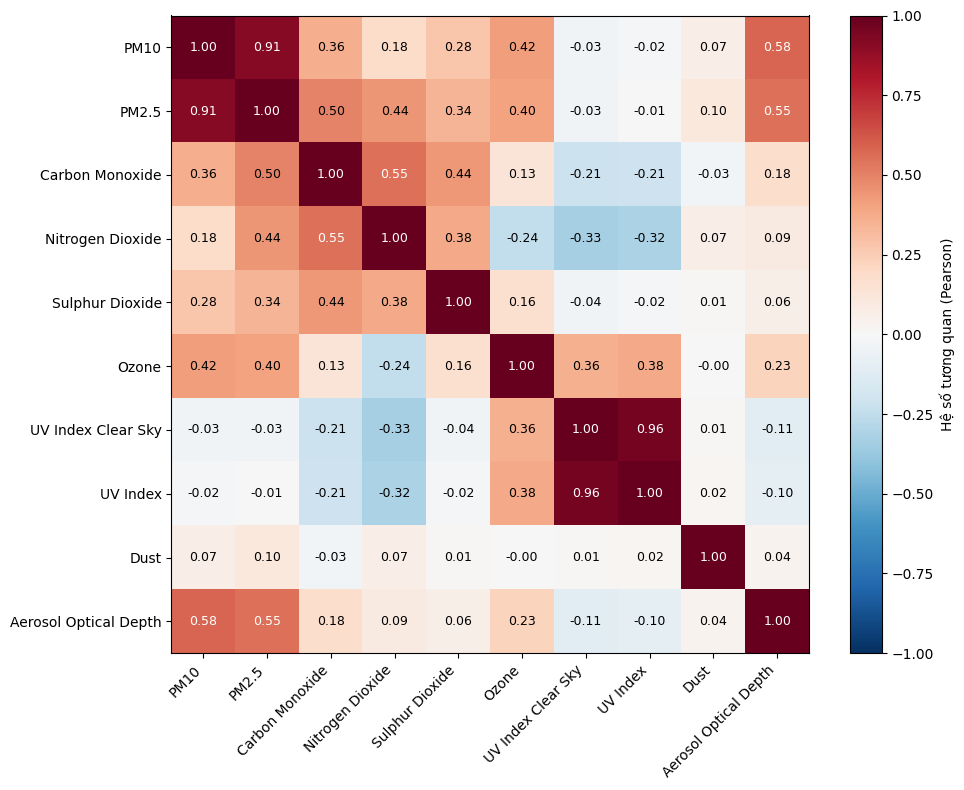

In [5]:
air_quality_cols = ['PM10', 'PM2.5', 'Carbon Monoxide', 'Nitrogen Dioxide', 'Sulphur Dioxide',
                     'Ozone', 'UV Index Clear Sky', 'UV Index', 'Dust', 'Aerosol Optical Depth']
corr_matrix = df[air_quality_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)

ax.set_xticks(range(len(air_quality_cols)))
ax.set_yticks(range(len(air_quality_cols)))
ax.set_xticklabels(air_quality_cols, rotation=45, ha='right')
ax.set_yticklabels(air_quality_cols)

for i in range(len(air_quality_cols)):
    for j in range(len(air_quality_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center',
                color='white' if abs(corr_matrix.iloc[i, j]) > 0.5 else 'black', fontsize=9)

plt.colorbar(im, ax=ax, label='Hệ số tương quan (Pearson)')
plt.tight_layout()
plt.show()

##### Vẽ biểu đồ đường (Lineplot) cho PM2.5

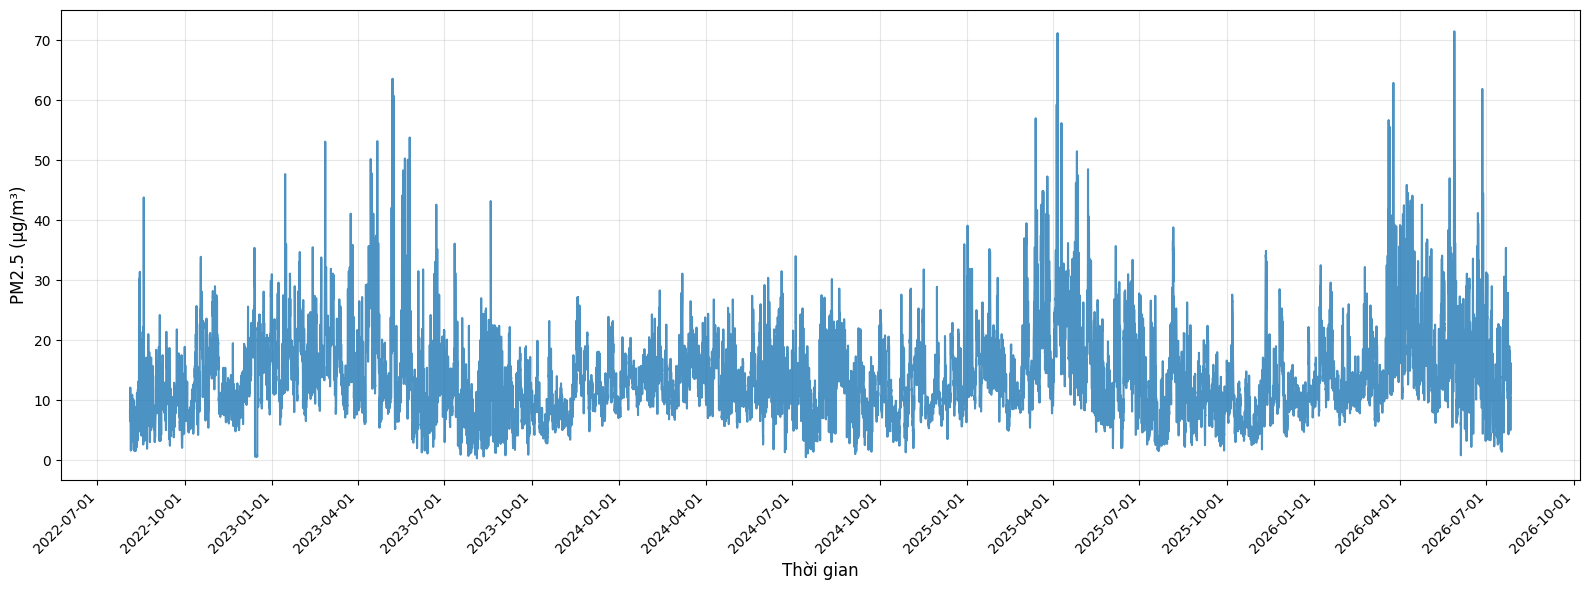

In [6]:
plt.figure(figsize=(16, 6))
plt.plot(df.index, df['PM2.5'], linewidth=1.5, color='#1f77b4', alpha=0.8)

# Format trục X để hiển thị thời gian
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))  # Hiển thị mỗi 3 tháng
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # Format: YYYY-MM-DD

# Rotate xticks để không bị đè
plt.xticks(rotation=45, ha='right')

plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Vẽ Moving Average để phát hiện xu hướng

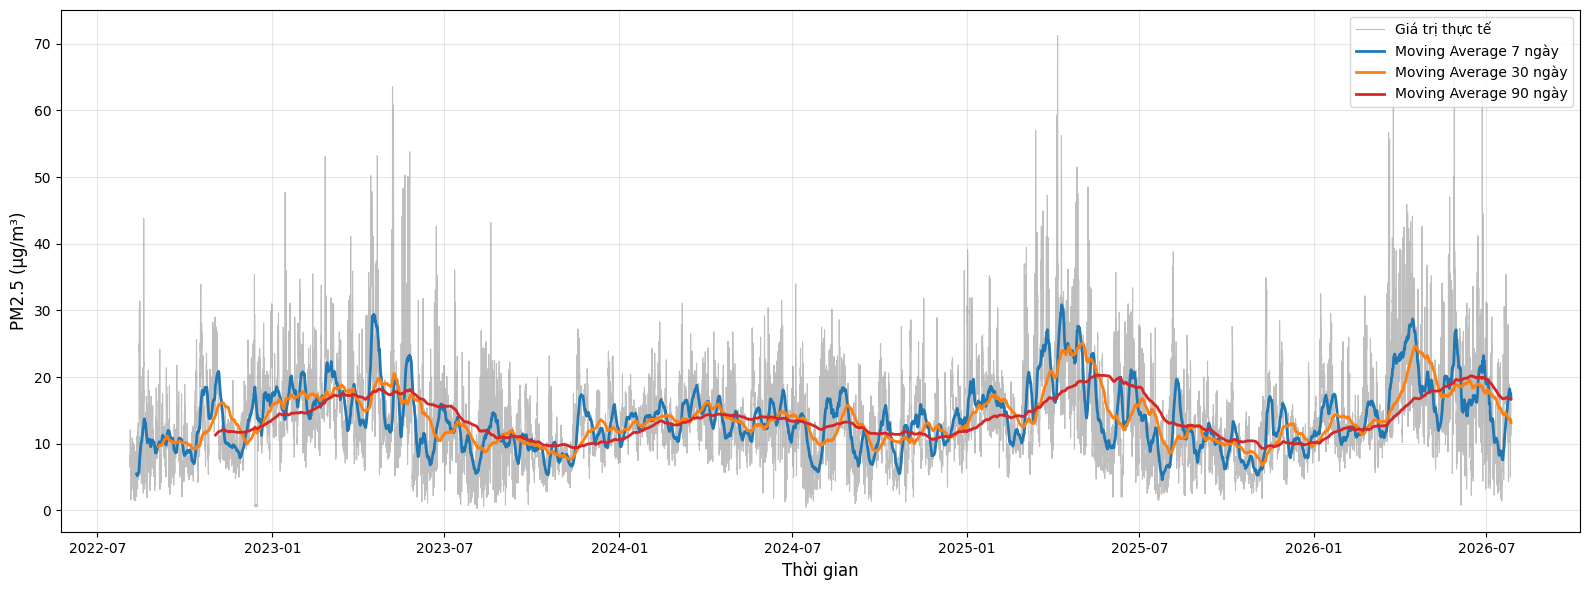

In [7]:
# Sắp xếp dữ liệu theo thời gian
df_sorted = df.sort_index()

# Tính moving average với các window khác nhau (dữ liệu theo giờ nên nhân 24 để đúng đơn vị ngày)
ma_7 = df_sorted['PM2.5'].rolling(window=24*7).mean()      # 7 ngày
ma_30 = df_sorted['PM2.5'].rolling(window=24*30).mean()    # 30 ngày
ma_90 = df_sorted['PM2.5'].rolling(window=24*90).mean()    # 90 ngày

plt.figure(figsize=(16, 6))
plt.plot(df_sorted.index, df_sorted['PM2.5'], label='Giá trị thực tế', linewidth=0.8, alpha=0.5, color='gray')
plt.plot(df_sorted.index, ma_7, label='Moving Average 7 ngày', linewidth=2, color='#1f77b4')
plt.plot(df_sorted.index, ma_30, label='Moving Average 30 ngày', linewidth=2, color='#ff7f0e')
plt.plot(df_sorted.index, ma_90, label='Moving Average 90 ngày', linewidth=2, color='#d62728')

plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Phân phối PM2.5 (Histogram & KDE)

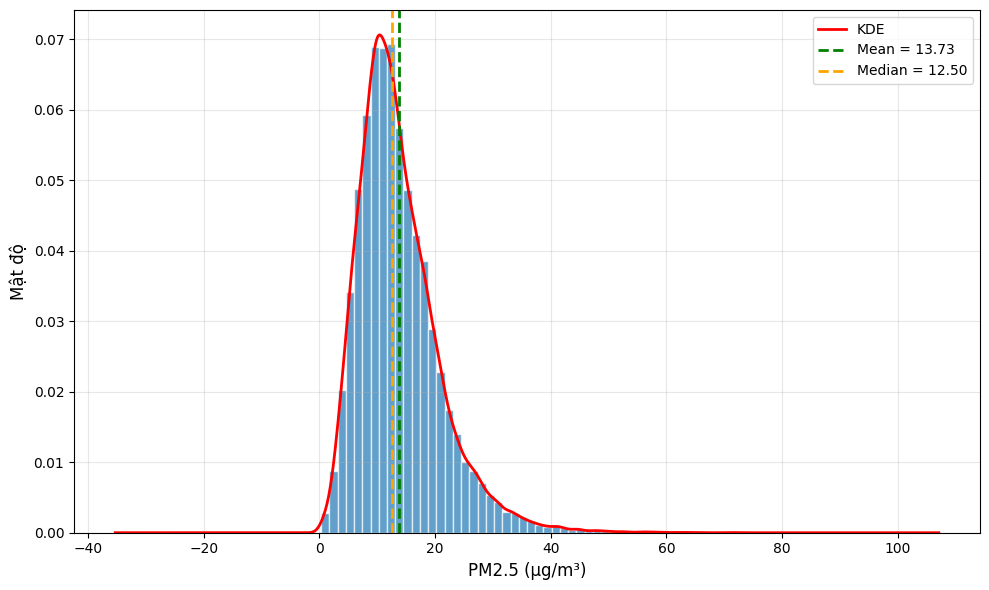

Skewness: 1.3434 -> Lệch phải (right-skewed, đuôi dài về giá trị cao)
Kurtosis (excess): 3.4982 -> Đuôi dày hơn phân phối chuẩn (nhiều outlier hơn)


In [8]:
pm25 = df_sorted['PM2.5'].dropna()

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(pm25, bins=50, color='#1f77b4', alpha=0.7, edgecolor='white', density=True)
pm25.plot(kind='kde', ax=ax, color='red', linewidth=2, label='KDE')

ax.axvline(pm25.mean(), color='green', linestyle='--', linewidth=2, label=f'Mean = {pm25.mean():.2f}')
ax.axvline(pm25.median(), color='orange', linestyle='--', linewidth=2, label=f'Median = {pm25.median():.2f}')

ax.set_xlabel('PM2.5 (µg/m³)', fontsize=12)
ax.set_ylabel('Mật độ', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

sk = stats.skew(pm25)
ku = stats.kurtosis(pm25)
print(f"Skewness: {sk:.4f} -> {'Lệch phải (right-skewed, đuôi dài về giá trị cao)' if sk > 0 else 'Lệch trái (left-skewed)'}")
print(f"Kurtosis (excess): {ku:.4f} -> {'Đuôi dày hơn phân phối chuẩn (nhiều outlier hơn)' if ku > 0 else 'Đuôi mỏng hơn phân phối chuẩn'}")

##### Outlier / Threshold Exceedance theo chuẩn WHO & QCVN Việt Nam

Tổng số ngày có dữ liệu: 1453
Số ngày vượt ngưỡng WHO (15 µg/m³): 510 (35.1%)
Số ngày vượt ngưỡng QCVN Việt Nam (50 µg/m³): 0 (0.0%)


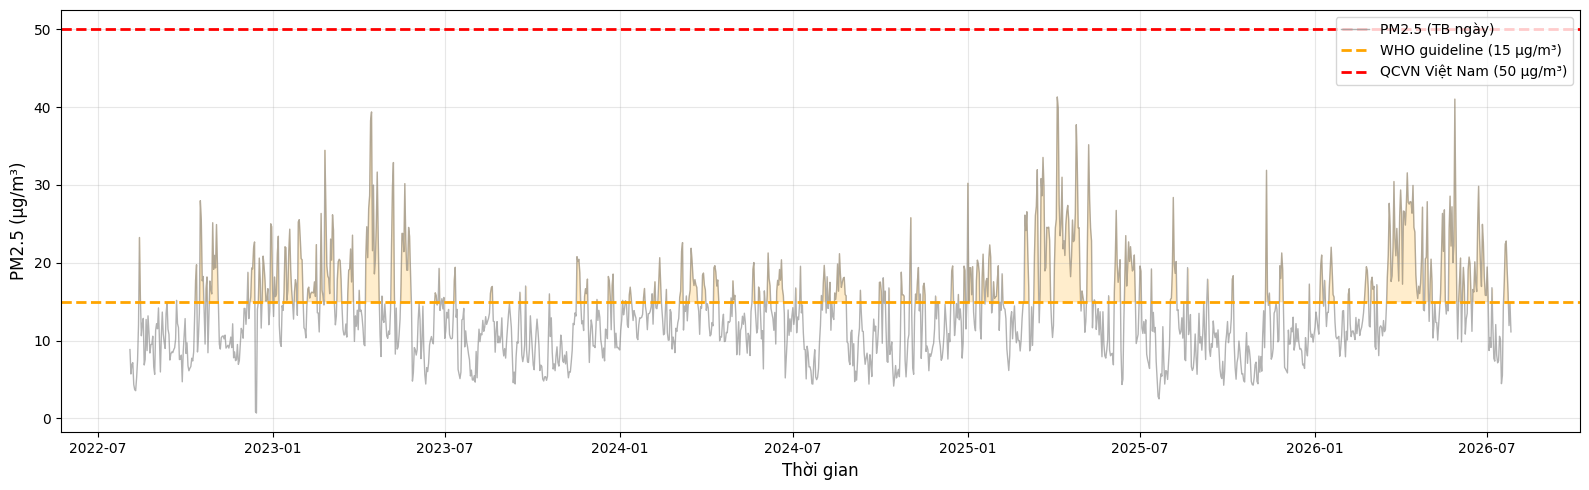

In [9]:
# Ngưỡng tham khảo cho PM2.5 trung bình 24h
who_guideline = 15  # WHO Air Quality Guideline 2021
qcvn_limit = 50      # QCVN 05:2013/BTNMT (Việt Nam)

daily_pm25 = df_sorted['PM2.5'].resample('D').mean().dropna()
total_days = len(daily_pm25)
exceed_who = (daily_pm25 > who_guideline).sum()
exceed_qcvn = (daily_pm25 > qcvn_limit).sum()

print(f"Tổng số ngày có dữ liệu: {total_days}")
print(f"Số ngày vượt ngưỡng WHO ({who_guideline} µg/m³): {exceed_who} ({exceed_who / total_days * 100:.1f}%)")
print(f"Số ngày vượt ngưỡng QCVN Việt Nam ({qcvn_limit} µg/m³): {exceed_qcvn} ({exceed_qcvn / total_days * 100:.1f}%)")

plt.figure(figsize=(16, 5))
plt.plot(daily_pm25.index, daily_pm25.values, color='gray', alpha=0.6, linewidth=1, label='PM2.5 (TB ngày)')
plt.axhline(who_guideline, color='orange', linestyle='--', linewidth=2, label=f'WHO guideline ({who_guideline} µg/m³)')
plt.axhline(qcvn_limit, color='red', linestyle='--', linewidth=2, label=f'QCVN Việt Nam ({qcvn_limit} µg/m³)')
plt.fill_between(daily_pm25.index, daily_pm25.values, who_guideline,
                  where=(daily_pm25.values > who_guideline), color='orange', alpha=0.2)

plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

##### Seasonal Subseries Plot: PM2.5 theo từng tháng

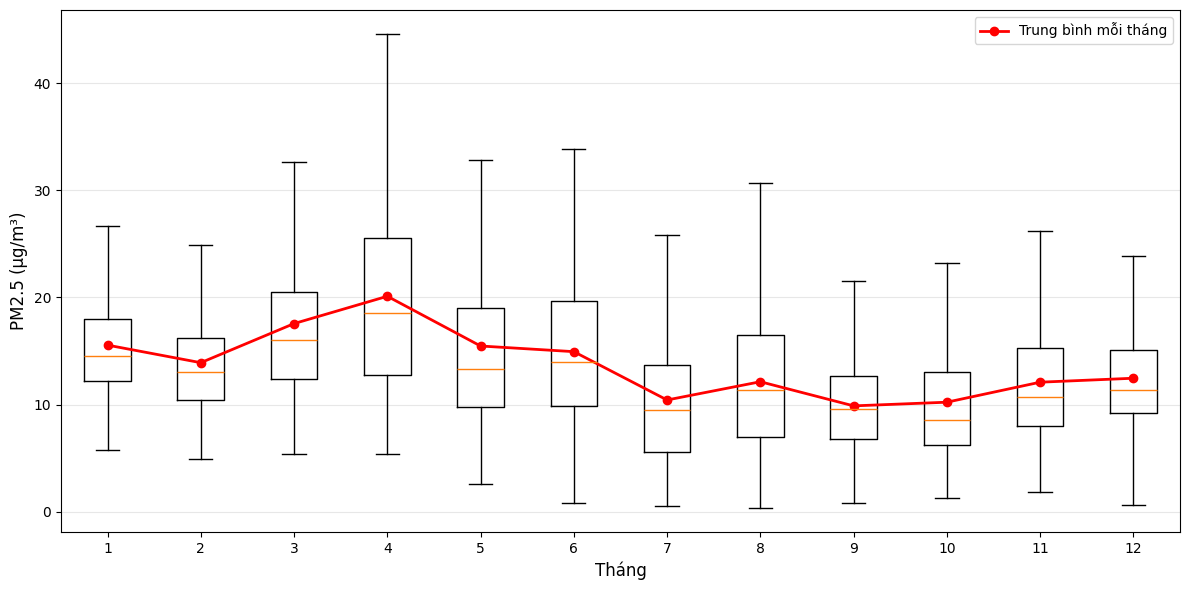

In [10]:
# Gom PM2.5 theo từng tháng (1-12), gộp dữ liệu của tất cả các năm cho mỗi tháng
months = range(1, 13)
data_by_month = [df_sorted[df_sorted['month'] == m]['PM2.5'].dropna().values for m in months]
month_means = [d.mean() for d in data_by_month]

plt.figure(figsize=(12, 6))
plt.boxplot(data_by_month, tick_labels=[str(m) for m in months], showfliers=False)
plt.plot(range(1, 13), month_means, color='red', marker='o', linewidth=2, label='Trung bình mỗi tháng')

plt.xlabel('Tháng', fontsize=12)
plt.ylabel('PM2.5 (µg/m³)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

##### Autocorrelation (ACF/PACF) của chuỗi gốc: theo giờ và theo ngày

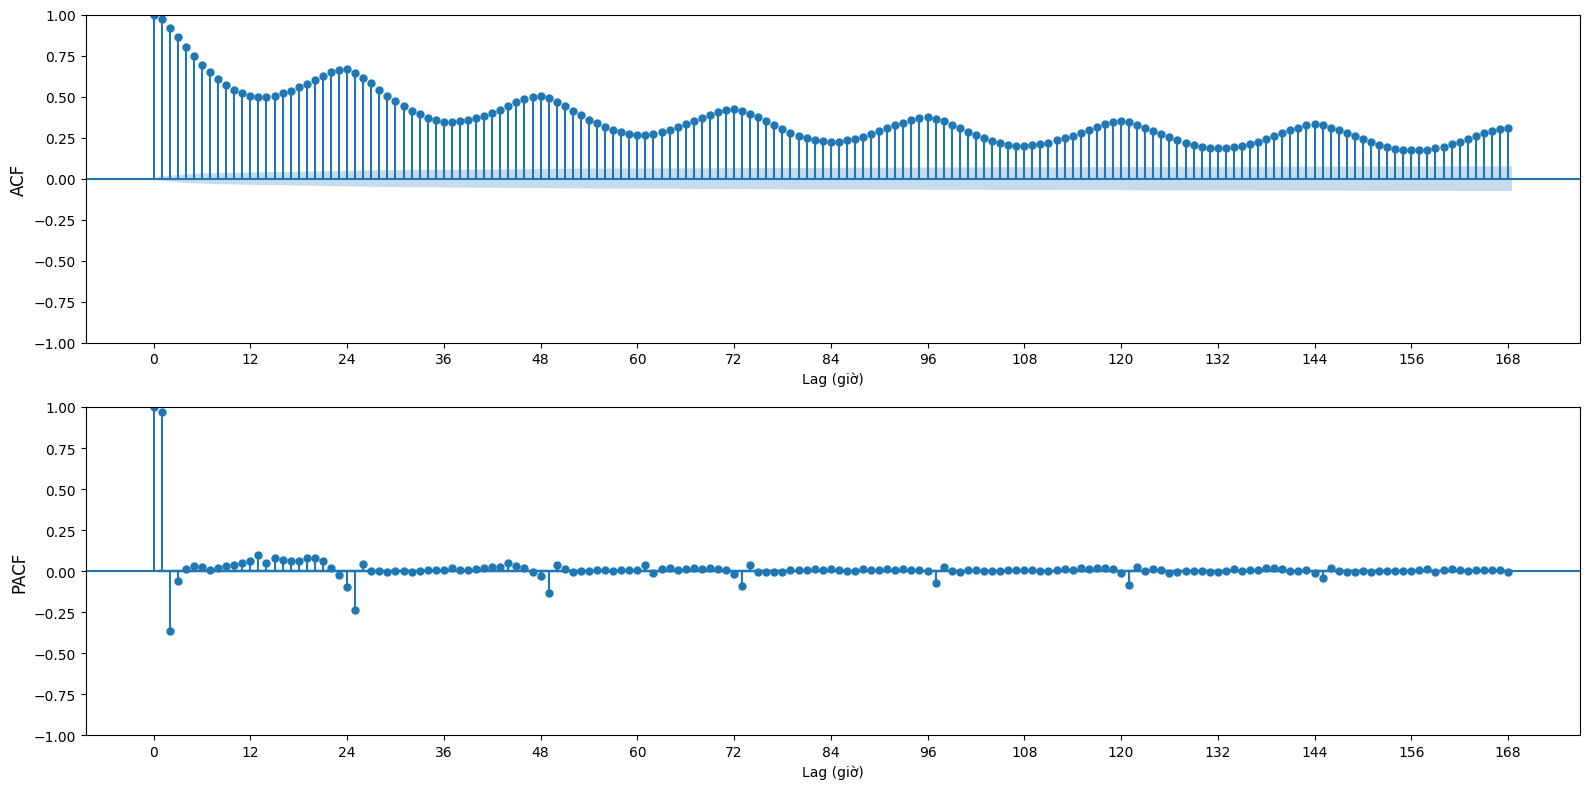

In [11]:
# Sắp xếp theo thời gian để đảm bảo đúng thứ tự chuỗi
df_sorted_acf = df.sort_index()
ts = df_sorted_acf['PM2.5']

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(ts, lags=168, ax=axes[0])
axes[0].set_title('')
axes[0].set_ylabel('ACF', fontsize=12)
axes[0].set_xlabel('Lag (giờ)')
axes[0].set_xticks(np.arange(0, 169, 12))

plot_pacf(ts, lags=168, ax=axes[1], method='ywm')
axes[1].set_title('')
axes[1].set_ylabel('PACF', fontsize=12)
axes[1].set_xlabel('Lag (giờ)')
axes[1].set_xticks(np.arange(0, 169, 12))

plt.tight_layout()
plt.show()

##### Time Series Decomposition (Trend + Seasonal + Residual)

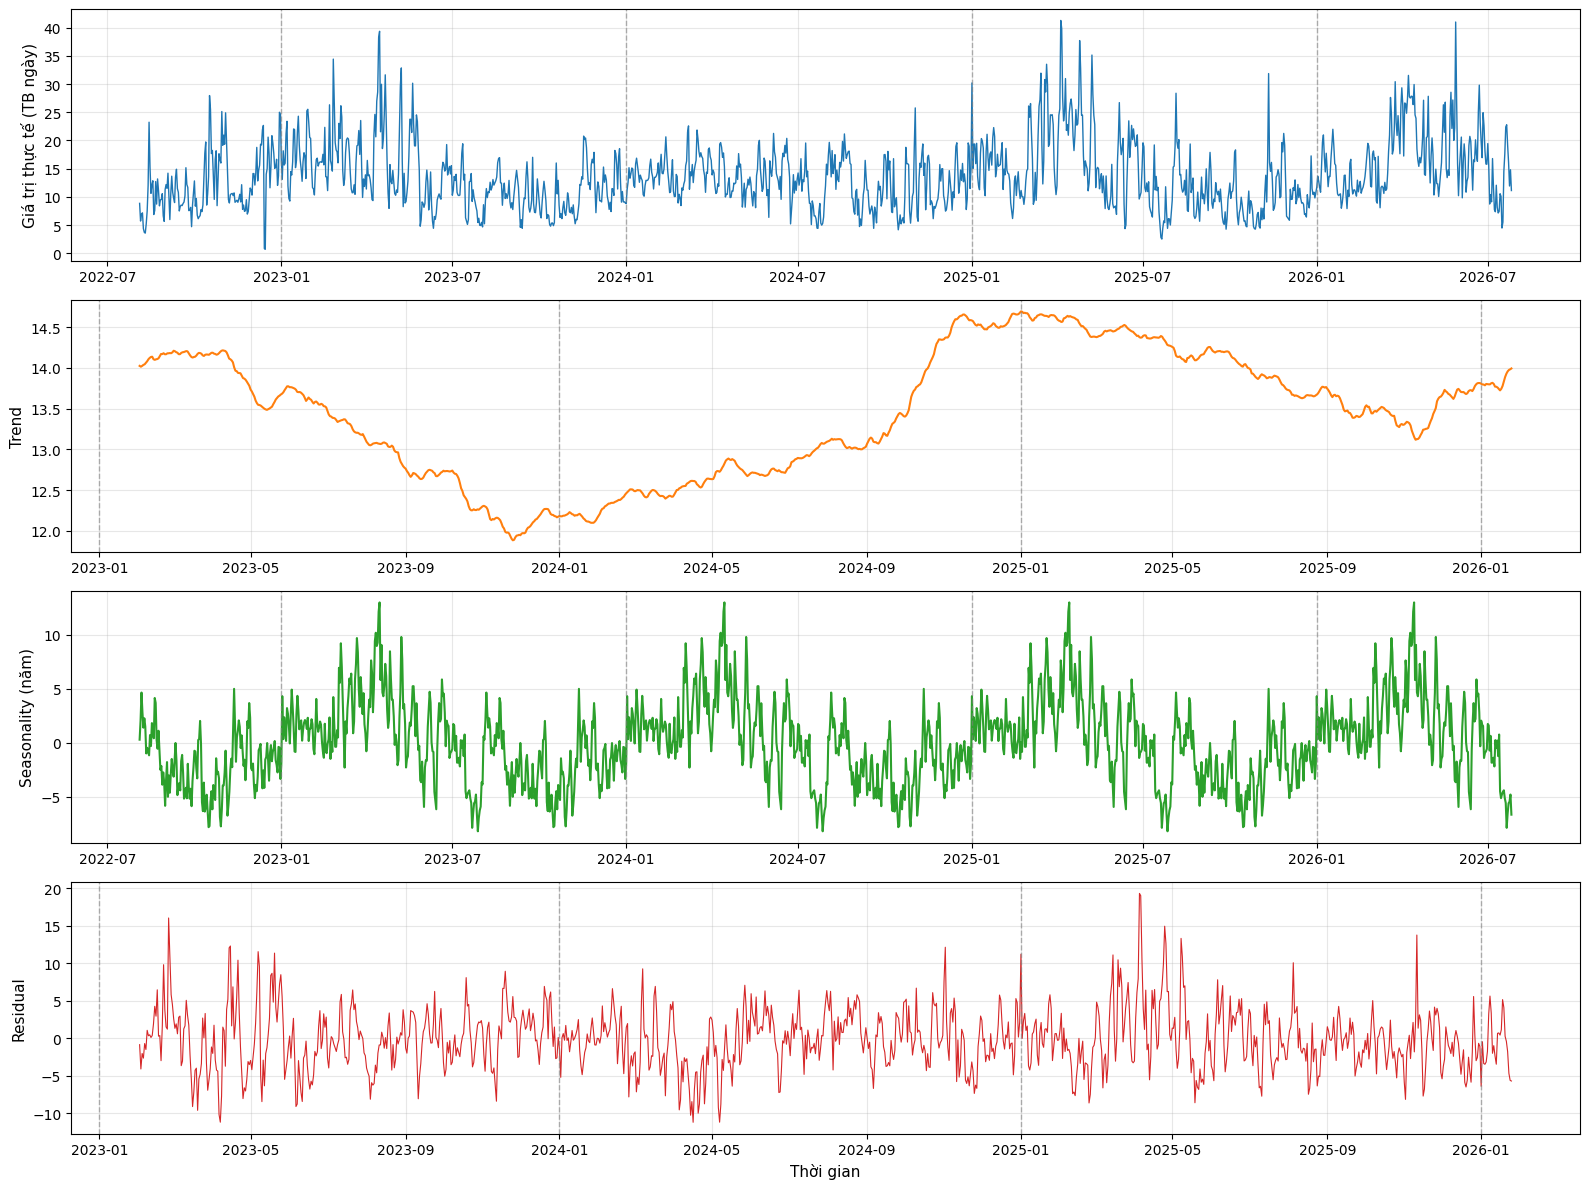

In [12]:
# Decomposition theo chu kỳ NĂM: resample về trung bình ngày, period=365 để bắt seasonality theo mùa/năm
daily_ts_decomp = df_sorted['PM2.5'].resample('D').mean()

decomposition_yearly = seasonal_decompose(daily_ts_decomp, model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(16, 12))

axes[0].plot(decomposition_yearly.observed.index, decomposition_yearly.observed.values, color='#1f77b4', linewidth=1)
axes[0].set_ylabel('Giá trị thực tế (TB ngày)', fontsize=11)
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomposition_yearly.trend.index, decomposition_yearly.trend.values, color='#ff7f0e', linewidth=1.5)
axes[1].set_ylabel('Trend', fontsize=11)
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomposition_yearly.seasonal.index, decomposition_yearly.seasonal.values, color='#2ca02c', linewidth=1.5)
axes[2].set_ylabel('Seasonality (năm)', fontsize=11)
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomposition_yearly.resid.index, decomposition_yearly.resid.values, color='#d62728', linewidth=0.8)
axes[3].set_ylabel('Residual', fontsize=11)
axes[3].set_xlabel('Thời gian', fontsize=11)
axes[3].grid(True, alpha=0.3)

# Vẽ đường nét đứt đứng để phân biệt ranh giới giữa các năm
year_boundaries = pd.date_range(
    start=f"{daily_ts_decomp.index.min().year}-01-01",
    end=f"{daily_ts_decomp.index.max().year + 1}-01-01",
    freq="YS"
)
for ax in axes:
    xlim = ax.get_xlim()  # lưu lại giới hạn trục X gốc trước khi thêm axvline
    for yb in year_boundaries:
        ax.axvline(yb, color='gray', linestyle='--', linewidth=1, alpha=0.6)
    ax.set_xlim(xlim)  # khôi phục giới hạn gốc để tránh axvline làm giãn trục X

plt.tight_layout()
plt.show()